# XXZ Chaos Diagnostics

This notebook rewrites `FastXXZChain` to support static, spectral, ETH, chaos, and quench diagnostics for the J1-J2 XXZ chain.

The implementation includes:
- full eigensystems
- momentum-sector diagonalisation
- entanglement entropy, spectrum, and entanglement energies
- level-spacing ratios and mean r statistics
- ETH fluctuation diagnostics
- Krylov time evolution and quench entanglement growth
- inverse participation ratio
- a high-level chaos diagnostic sweep

In [7]:
from xxz_chaos_tools import FastXXZChain

import matplotlib.pyplot as plt
import numpy as np


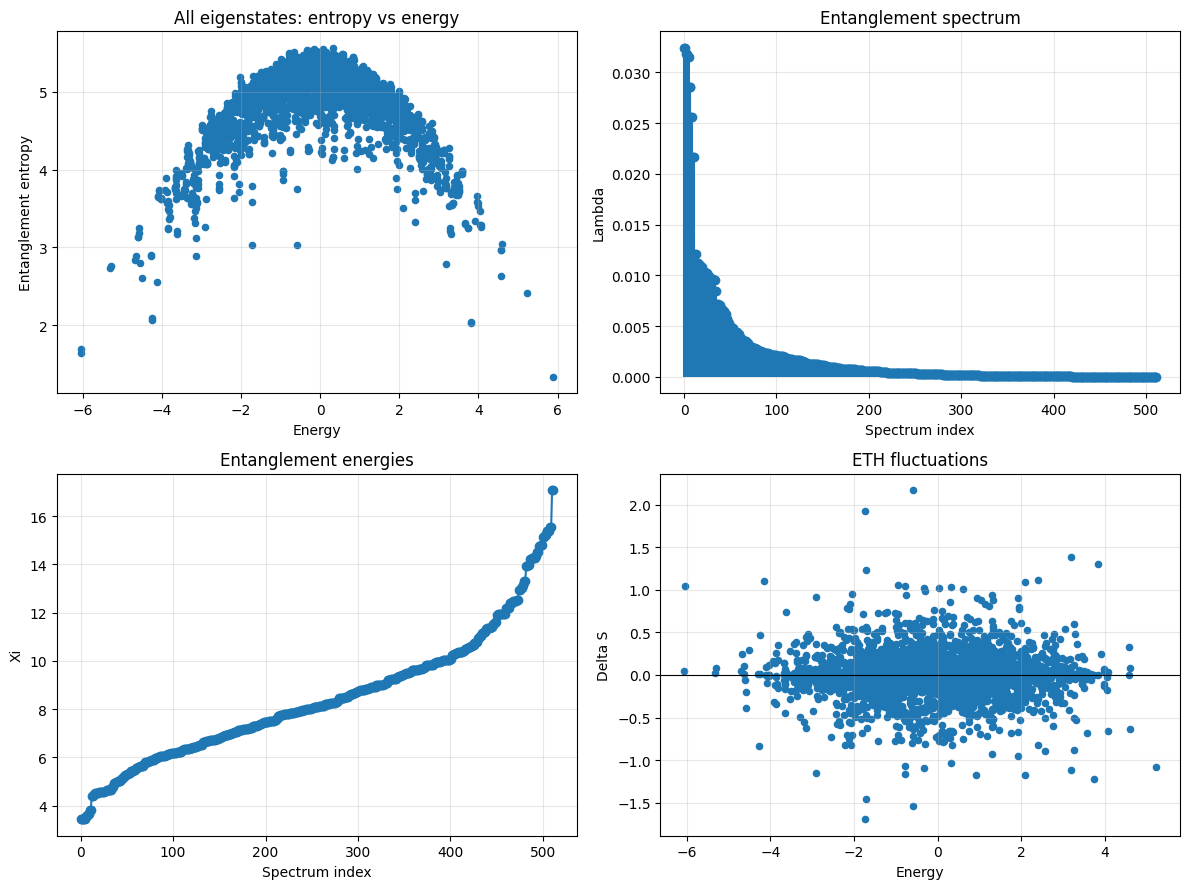

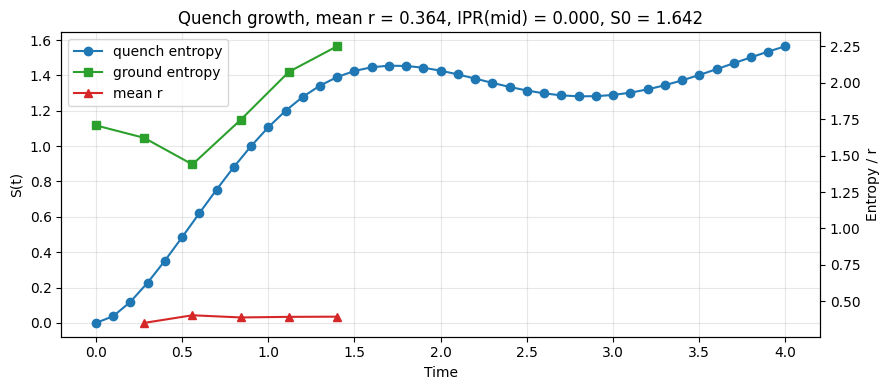

mean r in k=0 sector: 0.3644
direct entropy from the ground state: 1.6418


In [11]:
L = 18
chain = FastXXZChain(L=L, Nup=L // 2, periodic=True, J1xy=1.0, J1z=0.5, J2xy=0.2, J2z=0.0)

E, V = chain.eigensystem(kind='nnn', momentum_sector=0)
energies, entropies = chain.eigenstate_entropies(block_size=L // 2, kind='nnn', momentum_sector=0)
fluc_E, fluc = chain.eth_fluctuations(block_size=L // 2, kind='nnn', momentum_sector=0)
r_mean = chain.mean_r_statistic(kind='nnn', momentum_sector=0)
mid = len(E) // 2
lambdas = chain.entanglement_spectrum(V[:, mid], block_size=L // 2)
xi = chain.entanglement_energies(V[:, mid], block_size=L // 2)
ipr_mid = chain.inverse_participation_ratio(V[:, mid])
direct_entropy = chain.entanglement_entropy_from_state(V[:, 0], block_size=L // 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(E, entropies, s=20)
axes[0, 0].set_xlabel('Energy')
axes[0, 0].set_ylabel('Entanglement entropy')
axes[0, 0].set_title('All eigenstates: entropy vs energy')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].stem(np.arange(len(lambdas)), lambdas, basefmt=' ')
axes[0, 1].set_xlabel('Spectrum index')
axes[0, 1].set_ylabel('Lambda')
axes[0, 1].set_title('Entanglement spectrum')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(xi, marker='o')
axes[1, 0].set_xlabel('Spectrum index')
axes[1, 0].set_ylabel('Xi')
axes[1, 0].set_title('Entanglement energies')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(fluc_E, fluc, s=20)
axes[1, 1].axhline(0.0, color='black', linewidth=0.8)
axes[1, 1].set_xlabel('Energy')
axes[1, 1].set_ylabel('Delta S')
axes[1, 1].set_title('ETH fluctuations')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

psi0 = np.zeros(chain.hilbert_dimension(), dtype=complex)
psi0[0] = 1.0
times = np.linspace(0.0, 4.0, 41)
t, growth = chain.quench_entanglement_growth(psi0, times, block_size=L // 2, kind='nnn')

j2_values = np.linspace(0.0, 1.4, 6)
diag = chain.chaos_diagnostics(j2_values, block_size=L // 2, kind='nnn', momentum_sector=0)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(t, growth, marker='o', label='quench entropy')
ax1.set_xlabel('Time')
ax1.set_ylabel('S(t)')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(diag['J2_values'], diag['ground_entropy'], marker='s', label='ground entropy', color='tab:green')
ax2.plot(diag['J2_values'], diag['r_statistic'], marker='^', label='mean r', color='tab:red')
ax2.set_ylabel('Entropy / r')

ax1.set_title(f'Quench growth, mean r = {r_mean:.3f}, IPR(mid) = {ipr_mid:.3f}, S0 = {direct_entropy:.3f}')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.tight_layout()
plt.show()

print(f'mean r in k=0 sector: {r_mean:.4f}')
print(f'direct entropy from the ground state: {direct_entropy:.4f}')


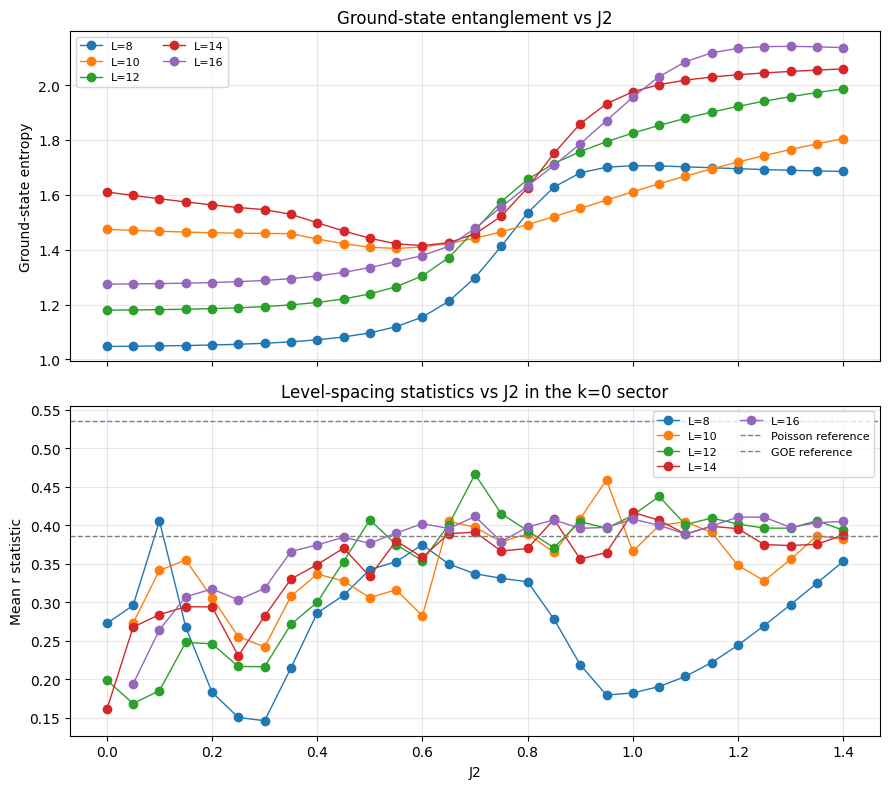

In [10]:
# Larger J2 sweep across several system sizes.
# This reuses the chaos-diagnostics API to compare thermal entanglement and level statistics.
L_values = [8, 10, 12, 14, 16]
J2_values = np.linspace(0.0, 1.4, 29)
block_size = None

fig, (ax_entropy, ax_r) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for L in L_values:
    chain = FastXXZChain(L=L, Nup=L // 2, periodic=True, J1xy=1.0, J1z=0.5, J2xy=0.0, J2z=0.0)
    block_size = L // 2
    diag = chain.chaos_diagnostics(J2_values, block_size=block_size, kind='nnn', momentum_sector=0)

    ax_entropy.plot(diag['J2_values'], diag['ground_entropy'], marker='o', linewidth=1, label=f'L={L}')
    ax_r.plot(diag['J2_values'], diag['r_statistic'], marker='o', linewidth=1, label=f'L={L}')

ax_entropy.set_ylabel('Ground-state entropy')
ax_entropy.set_title('Ground-state entanglement vs J2')
ax_entropy.grid(True, alpha=0.3)
ax_entropy.legend(ncol=2, fontsize=8)

ax_r.axhline(0.386, color='tab:gray', linestyle='--', linewidth=1, label='Poisson reference')
ax_r.axhline(0.536, color='tab:purple', linestyle='--', linewidth=1, label='GOE reference')
ax_r.set_xlabel('J2')
ax_r.set_ylabel('Mean r statistic')
ax_r.set_title('Level-spacing statistics vs J2 in the k=0 sector')
ax_r.grid(True, alpha=0.3)
ax_r.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()
